### 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## 2. Load Data

In [3]:
df = pd.read_csv("abfss://25d8921d-addf-494b-91f2-fff19310b51e@onelake.dfs.fabric.microsoft.com/3ce0b06e-1da5-4c83-8d2d-149c9bcba976/Files/bank_transactions_data_2 (1).csv")

##  3. Basic Information

In [4]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [5]:
df.shape

(2512, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [7]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [8]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

## 4. Data cleaning

In [9]:
# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [10]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP_Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

In [11]:
#Checking missing value
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP_Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [12]:
#Remove Duplicates
df.drop_duplicates(inplace=True)

In [13]:
#Convert Date Column
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

##  5. Feature Engineering

In [14]:
df['Hour'] = df['TransactionDate'].dt.hour
df['Hour']

0       16
1       16
2       18
3       16
4       17
        ..
2507    17
2508    17
2509    17
2510    16
2511    16
Name: Hour, Length: 2512, dtype: int32

In [15]:
df['Day'] = df['TransactionDate'].dt.day_name()
df['Day']

0         Tuesday
1         Tuesday
2          Monday
3          Friday
4          Monday
          ...    
2507    Wednesday
2508    Wednesday
2509       Monday
2510       Friday
2511      Tuesday
Name: Day, Length: 2512, dtype: object

In [16]:
df['Month'] = df['TransactionDate'].dt.month_name()
df['Month']

0          April
1           June
2           July
3            May
4        October
          ...   
2507       April
2508       March
2509      August
2510    February
2511    February
Name: Month, Length: 2512, dtype: object

##  6. Exploratory Data Analysis

In [17]:
# Total Transactions
print("Total Transactions:", len(df))

# Average Transaction Amount
print("Average Transaction Amount:", df["TransactionAmount"].mean())

# Maximum Transaction
print("Highest Transaction:", df["TransactionAmount"].max())

# Minimum Transaction
print("Lowest Transaction:", df["TransactionAmount"].min())

Total Transactions: 2512
Average Transaction Amount: 297.5937778662421
Highest Transaction: 1919.11
Lowest Transaction: 0.26


## 7. Data Visualization

#### Transaction Type Count

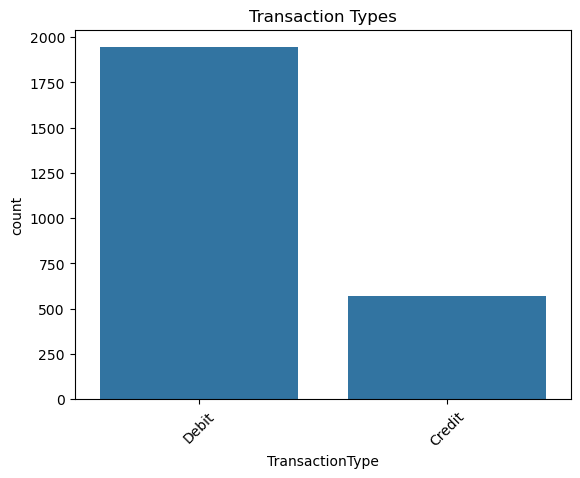

In [18]:
sns.countplot(x='TransactionType', data=df)
plt.title("Transaction Types")
plt.xticks(rotation=45)
plt.show()

#### Usage Channel

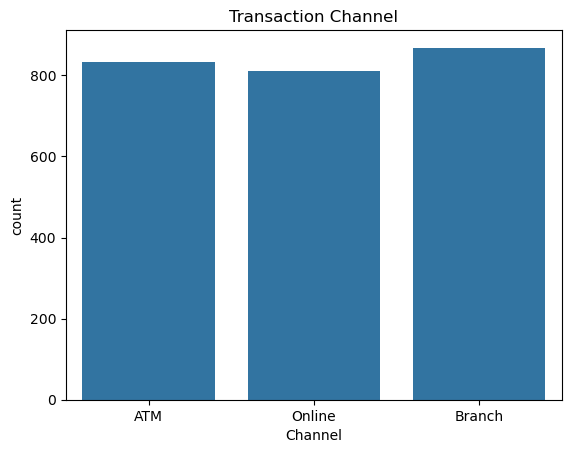

In [19]:
sns.countplot(x='Channel', data=df)
plt.title("Transaction Channel")
plt.show()

#### Top 10 Locations

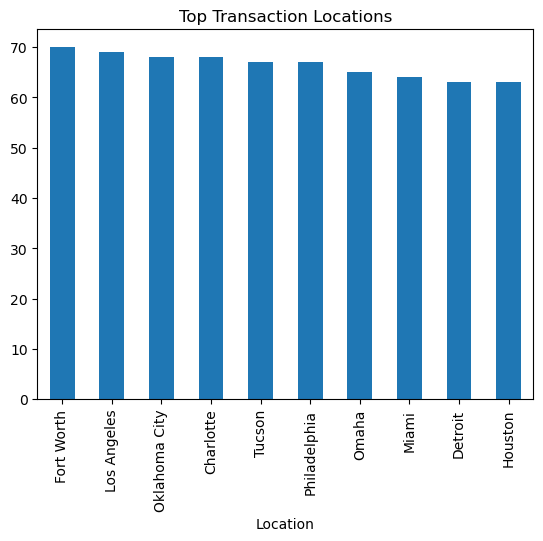

In [20]:
df['Location'].value_counts().head(10).plot(kind='bar')
plt.title("Top Transaction Locations")
plt.show()

#### Transaction Amount Distribution

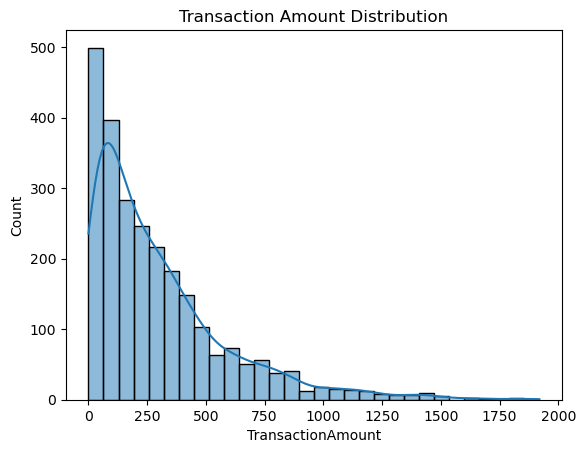

In [21]:
sns.histplot(df['TransactionAmount'], bins=30, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

####  Customer Age Distribution

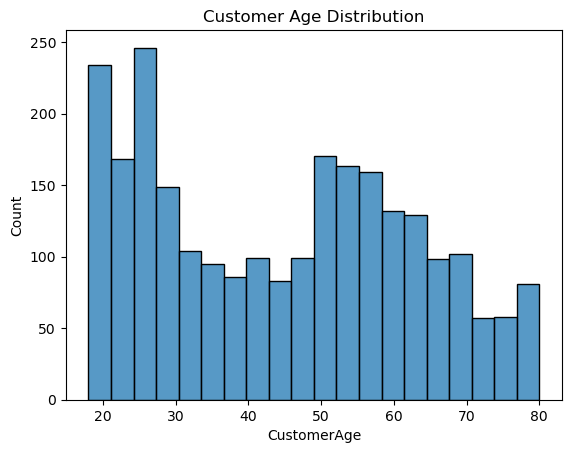

In [22]:
sns.histplot(df['CustomerAge'], bins=20)
plt.title("Customer Age Distribution")
plt.show()

#### Occupation Analysis

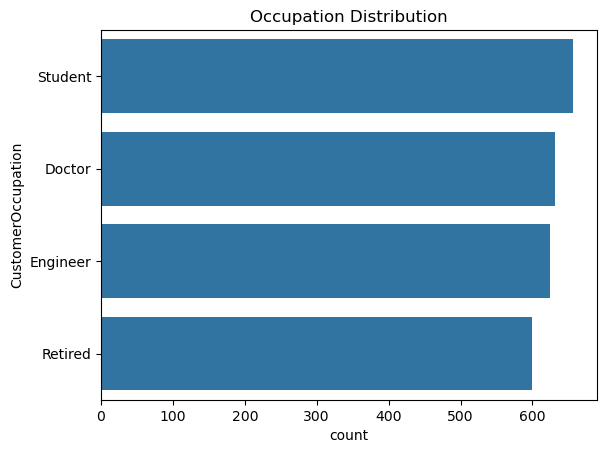

In [23]:
sns.countplot(y='CustomerOccupation', data=df,
order=df['CustomerOccupation'].value_counts().index)
plt.title("Occupation Distribution")
plt.show()

#### Login Attempts

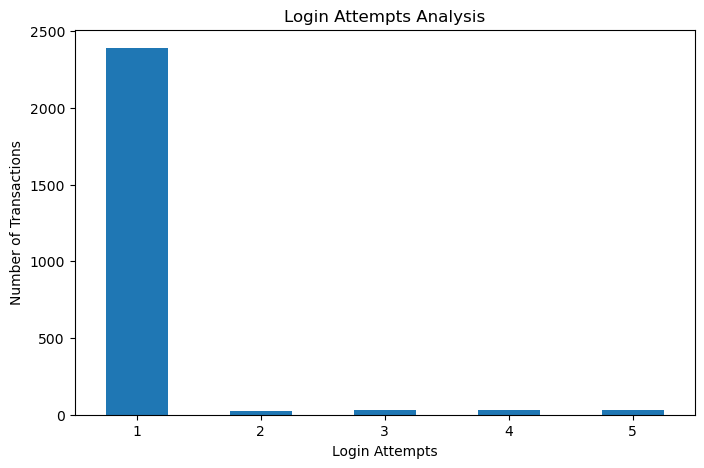

In [24]:
df['LoginAttempts'].value_counts().sort_index().plot(
    kind='bar', figsize=(8,5)
)
plt.title("Login Attempts Analysis")
plt.xlabel("Login Attempts")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

#### Monthly Transaction Trend

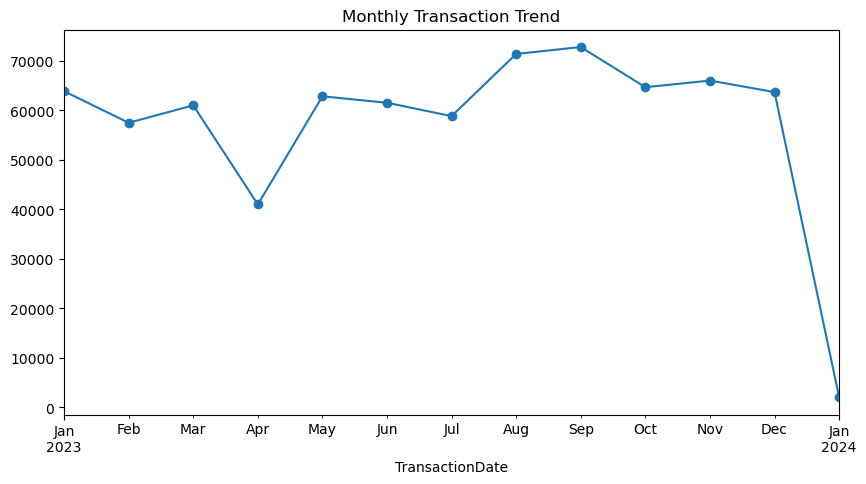

In [25]:
monthly = df.groupby(df['TransactionDate'].dt.to_period('M'))['TransactionAmount'].sum()

monthly.plot(figsize=(10,5), marker='o')
plt.title("Monthly Transaction Trend")
plt.show()

#### Hourly Transaction Trend


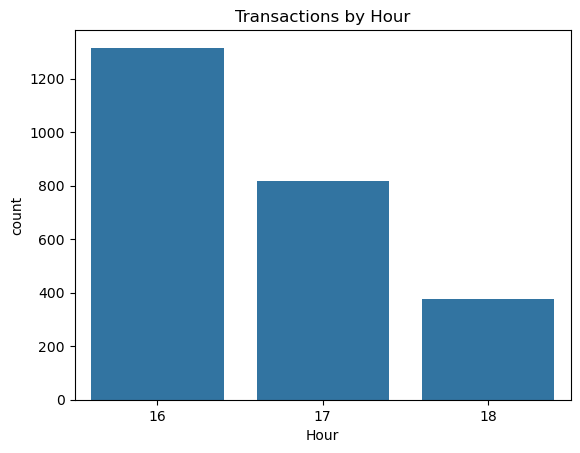

In [26]:
sns.countplot(x="Hour", data=df)
plt.title("Transactions by Hour")
plt.show()

#### Balance vs Transaction Amount

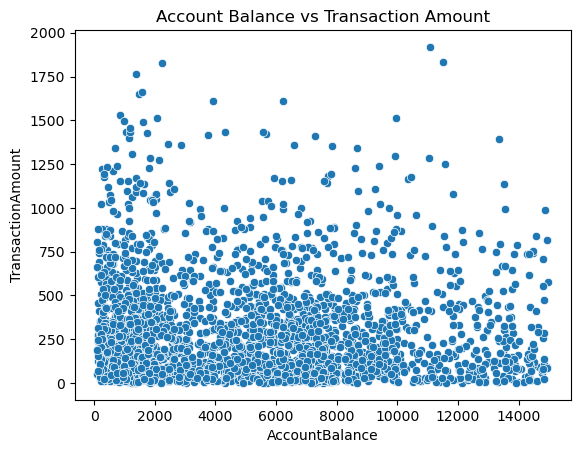

In [27]:
sns.scatterplot(
    x="AccountBalance",
    y="TransactionAmount",
    data=df
)

plt.title("Account Balance vs Transaction Amount")
plt.show()

####  Correlation Heatmap

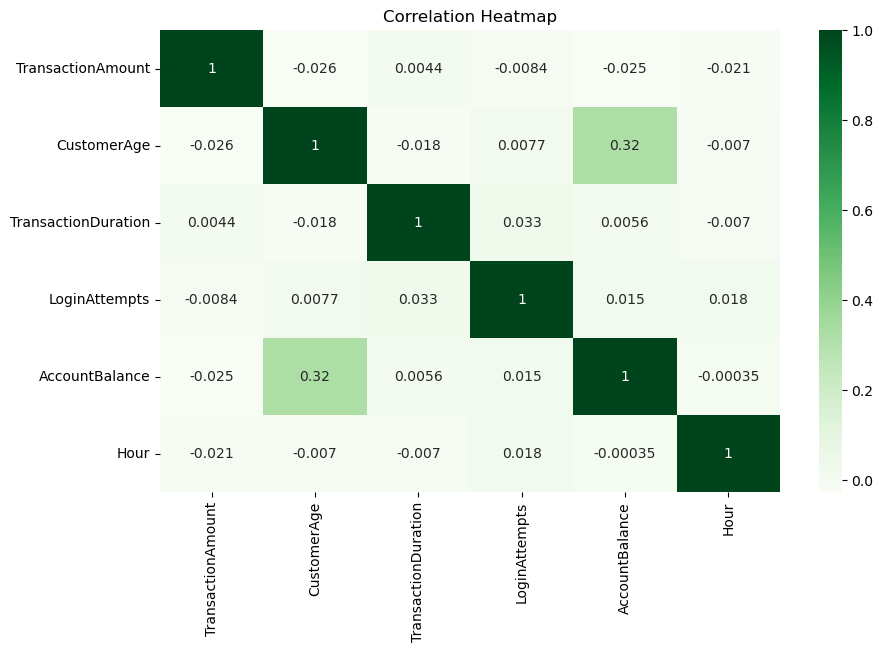

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Greens')
plt.title("Correlation Heatmap")
plt.show()

## 8. Suspicious Activity Analysis

In [29]:
suspicious = df[
    (df["LoginAttempts"] > 3) &
    (df["TransactionAmount"] > 5000)
]

print("Suspicious Transactions:")
print(suspicious)


Suspicious Transactions:
Empty DataFrame
Columns: [TransactionID, AccountID, TransactionAmount, TransactionDate, TransactionType, Location, DeviceID, IP_Address, MerchantID, Channel, CustomerAge, CustomerOccupation, TransactionDuration, LoginAttempts, AccountBalance, PreviousTransactionDate, Hour, Day, Month]
Index: []


## 9. Top Customers by Transaction Amount

AccountID
AC00460    5570.34
AC00363    4702.91
AC00337    4393.41
AC00021    4263.34
AC00439    4185.81
AC00385    4141.20
AC00071    4050.12
AC00265    3953.60
AC00136    3880.53
AC00179    3819.73
Name: TransactionAmount, dtype: float64


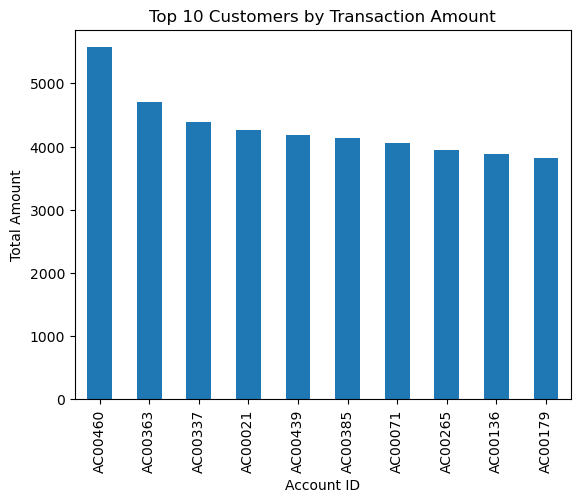

In [30]:
top_customers = df.groupby("AccountID")["TransactionAmount"].sum().sort_values(ascending=False).head(10)

print(top_customers)

top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Transaction Amount")
plt.xlabel("Account ID")
plt.ylabel("Total Amount")
plt.show()

## 10.Final Insight

In [31]:
print("""
PROJECT INSIGHTS:

1. Most common transaction type identified.
2. Highest activity channel detected.
3. Top locations with maximum transactions found.
4. Login attempts reveal possible suspicious behavior.
5. Peak transaction hours identified.
6. High-value customers identified.
7. Monthly trends analyzed successfully.
""")


PROJECT INSIGHTS:

1. Most common transaction type identified.
2. Highest activity channel detected.
3. Top locations with maximum transactions found.
4. Login attempts reveal possible suspicious behavior.
5. Peak transaction hours identified.
6. High-value customers identified.
7. Monthly trends analyzed successfully.

